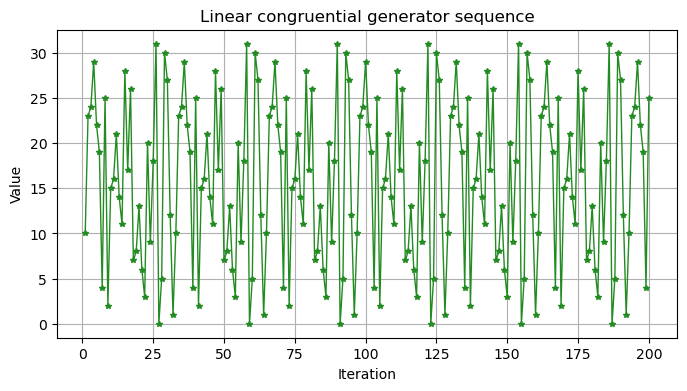

In [21]:
import matplotlib.pyplot as plt
def generator_simple_congruence(a, b, m, seed, n):
    x = seed
    seq = []
    for _ in range(n):
        x = (a * x + b) % m
        seq.append(x)
    return seq
gen = generator_simple_congruence(5, 5, 32, 1, 200)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(gen)+1), gen, marker='*', linestyle='-' , linewidth=1, markersize=4 , color='forestgreen')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Linear congruential generator sequence')
plt.grid(True)
plt.show()

[18, 4, 17, 8, 2, 9, 26, 4, 9, 0]


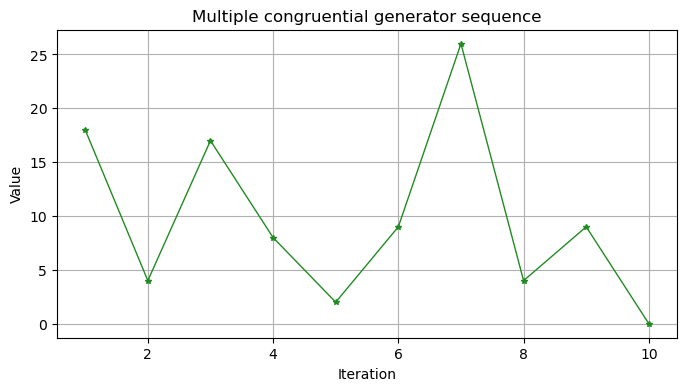

[0.18, 0.04, 0.17, 0.08, 0.02, 0.09, 0.26, 0.04, 0.09]


In [42]:
def generator_multiple_congruence(a, b, c, m, seed1, seed2, n):
    x1 = seed1
    x2 = seed2
    seq = []
    for _ in range(n):
        x_new = (a * x1 + b * x2 + c) % m
        seq.append(x_new)
        x2 = x1
        x1 = x_new
    return seq

gen1 = generator_multiple_congruence(5, 3, 7, 32, 1, 2, 10)
print(gen1) 
plt.figure(figsize=(8,4))
plt.plot(range(1, len(gen1)+1), gen1, marker='*', linestyle='-' , linewidth=1, markersize=4 , color='forestgreen')
plt.xlabel('Iteration')     
plt.ylabel('Value')
plt.title('Multiple congruential generator sequence')
plt.grid(True)
plt.show()

gen2=[]
for i in range(len(gen1)-1):
    gen2.append((gen1[i]/100))
print(gen2)

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

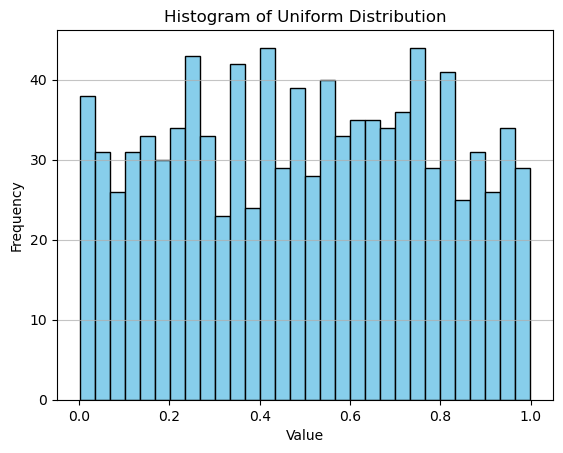

In [4]:
uniform_data = np.random.uniform(0, 1, 1000)
plt.hist(uniform_data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

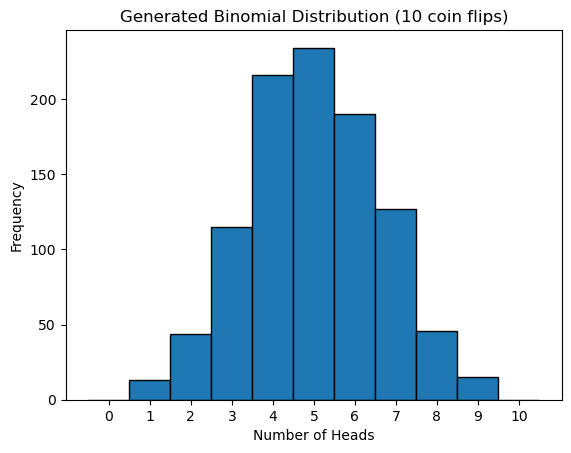

In [ ]:
binomial_data = np.random.binomial(n=10, p=0.5, size=1000)
plt.hist(binomial_data, bins=range(12), edgecolor='black', align='left')
plt.xticks(range(0, 11))
plt.title('Generated Binomial Distribution ')
plt.xlabel('Number of Heads')
plt.ylabel('Frequency')
plt.show()

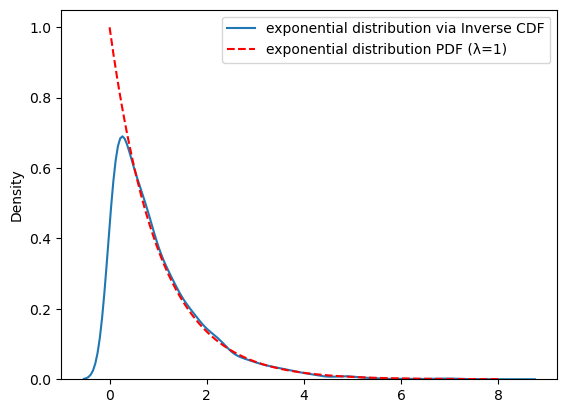

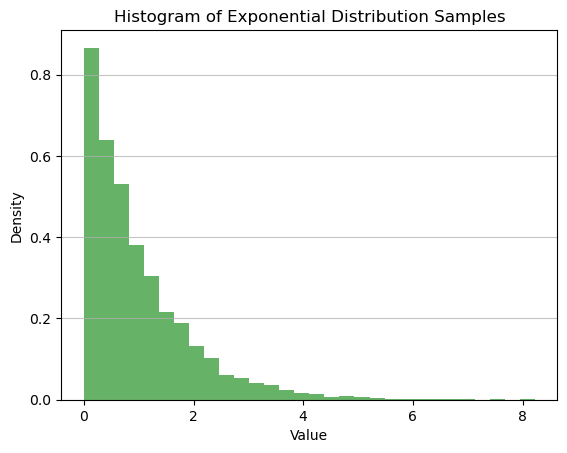

In [12]:
def inverse_cdf_exponential(u, lam=1.0):
    return -np.log(1 - u) / lam

u = np.random.uniform(0, 1, 5000)
exponential_samples = inverse_cdf_exponential(u, lam=1.0)

sns.kdeplot(exponential_samples, label='exponential distribution via Inverse CDF')
x = np.linspace(0, 8, 100)
plt.plot(x, 1.0 * np.exp(-1.0 * x), 'r--', label='exponential distribution PDF (λ=1)')
plt.legend()
plt.show()
plt.hist(exponential_samples, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Exponential Distribution Samples')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

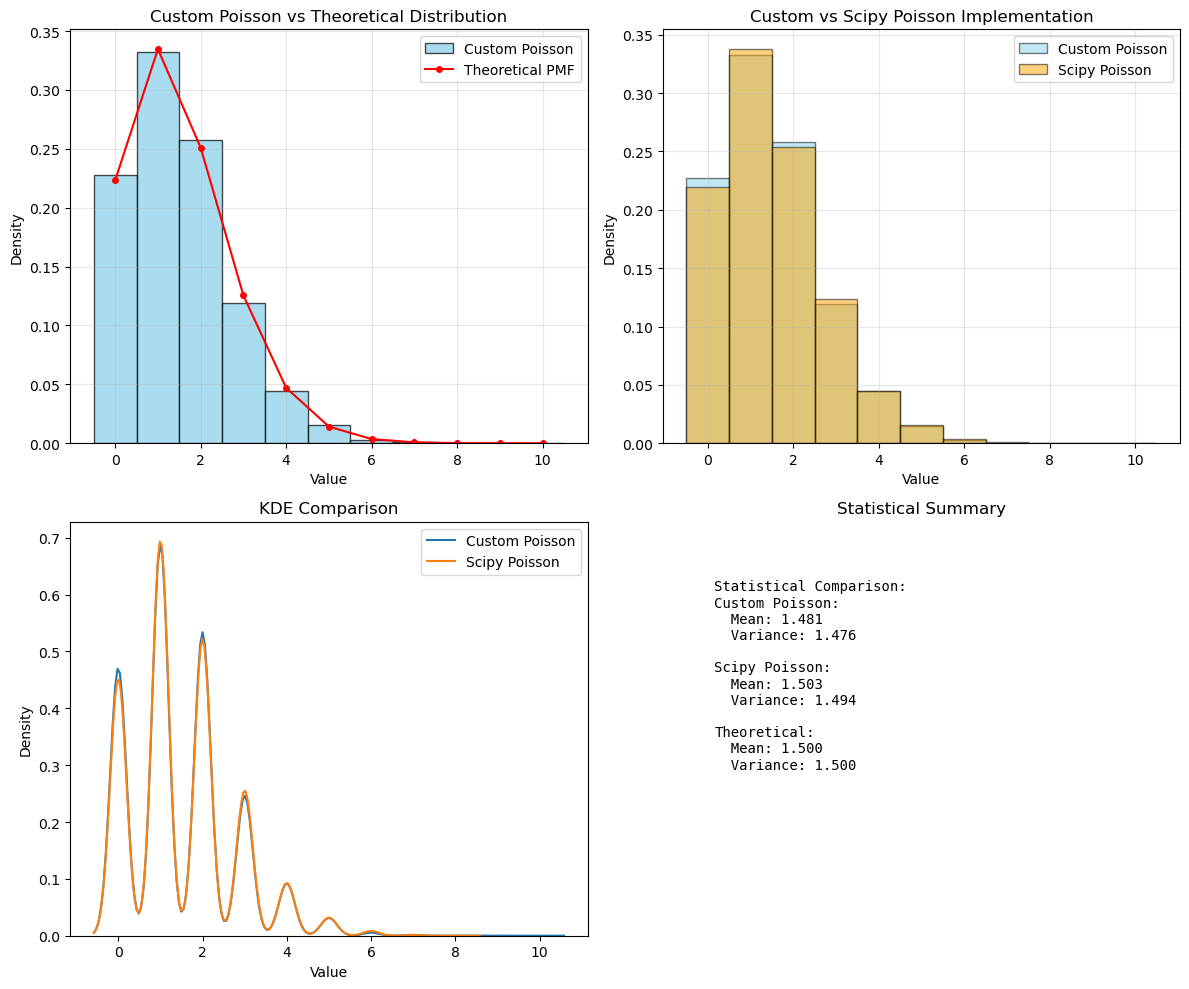

In [27]:
def inverse_transform_poisson(lam, size=1):
    samples = []
    
    for _ in range(size):
        u = np.random.uniform(0, 1)  
        x = 0
        F_x = np.exp(-lam)
        cdf = F_x
        
        while u > cdf:
            x += 1
            F_x = F_x * lam / x 
            cdf += F_x
        
        samples.append(x)
    
    return np.array(samples)

lam = 1.5
size = 10000
custom_poisson = inverse_transform_poisson(lam=lam, size=size)
scipy_poisson = np.random.poisson(lam=lam, size=size)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].hist(custom_poisson, bins=range(0, max(custom_poisson)+2), 
                alpha=0.7, color='skyblue', edgecolor='black', 
                align='left', density=True, label='Custom Poisson')
x_vals = np.arange(0, max(custom_poisson)+1)
axes[0, 0].plot(x_vals, stats.poisson.pmf(x_vals, lam), 
                'ro-', markersize=4, label='Theoretical PMF')
axes[0, 0].set_title('Custom Poisson vs Theoretical Distribution')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(custom_poisson, bins=range(0, max(max(custom_poisson), max(scipy_poisson))+2), 
                alpha=0.5, color='skyblue', edgecolor='black', 
                align='left', density=True, label='Custom Poisson')
axes[0, 1].hist(scipy_poisson, bins=range(0, max(max(custom_poisson), max(scipy_poisson))+2), 
                alpha=0.5, color='orange', edgecolor='black', 
                align='left', density=True, label='Scipy Poisson')
axes[0, 1].set_title('Custom vs Scipy Poisson Implementation')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)



sns.kdeplot(custom_poisson, label='Custom Poisson', ax=axes[1, 0])
sns.kdeplot(scipy_poisson, label='Scipy Poisson', ax=axes[1, 0])
axes[1, 0].set_title('KDE Comparison')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

stats_text = f"""
Statistical Comparison:
Custom Poisson:
  Mean: {np.mean(custom_poisson):.3f}
  Variance: {np.var(custom_poisson):.3f}
  
Scipy Poisson:
  Mean: {np.mean(scipy_poisson):.3f}
  Variance: {np.var(scipy_poisson):.3f}
  
Theoretical:
  Mean: {lam:.3f}
  Variance: {lam:.3f}
"""
axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, 
                fontfamily='monospace', verticalalignment='top')
axes[1, 1].set_title('Statistical Summary')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


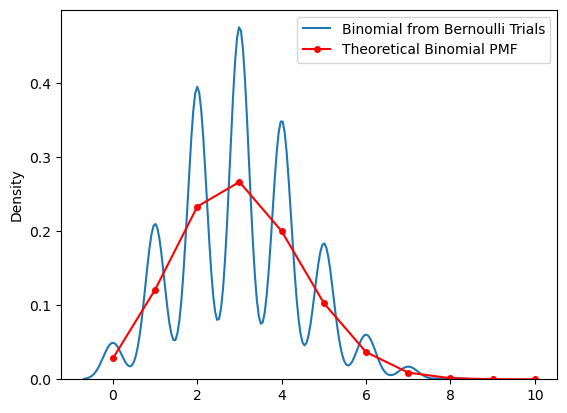

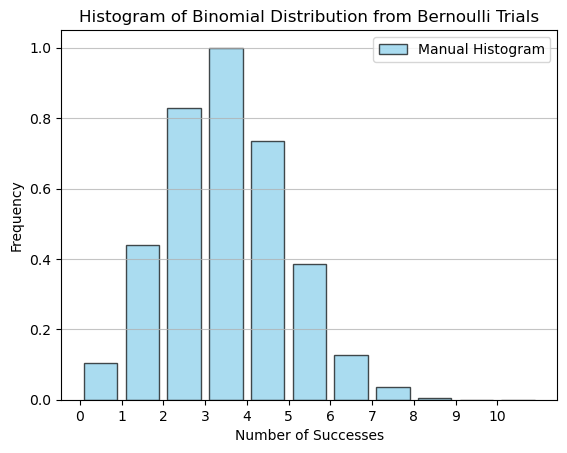

In [57]:
def bernoulli_trials(p, size=1):
    return np.random.binomial(1, p, size)

def binomial_from_bernoulli(n, p, size=1):
    
    binomial_samples = []
    
    for _ in range(size):
        bernoulli_sample = bernoulli_trials(p, n)
        binomial_samples.append(np.sum(bernoulli_sample))
    
    return np.array(binomial_samples)
n = 10     
p = 0.3    
size = 10000 


binomial_custom = binomial_from_bernoulli(n, p, size)
sns.kdeplot(binomial_custom, label='Binomial from Bernoulli Trials')
x_vals = np.arange(0, n+1)
plt.plot(x_vals, stats.binom.pmf(x_vals, n, p),  'ro-', markersize=4, label='Theoretical Binomial PMF')
plt.legend()
plt.show()

counts, bin_edges = np.histogram(binomial_custom  , bins=range(n+2))
normalized_counts = counts / np.max(counts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, normalized_counts, width=0.8, alpha=0.7, color='skyblue', 
        edgecolor='black', align='center', label='Manual Histogram')
plt.xticks(range(0, n+1))
plt.title('Histogram of Binomial Distribution from Bernoulli Trials')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

In [ ]:
import numpy as np
from scipy.stats import norm, beta, gamma

def generate_from_scipy_distribution(distribution, size=10, **params):
    u = np.random.uniform(0, 1, size)
    return distribution.ppf(u, **params)
def inverse_transform_sampling(inverse_cdf, size=1000):
    u = np.random.uniform(0, 1, size)
    return inverse_cdf(u)
def exponential_inverse_cdf(u, lam=1.0):
    return -np.log(1 - u) / lam
def pareto_inverse_cdf(u, xm=1.0, alpha=2.5):
    return xm / (1 - u)**(1/alpha)
def cauchy_inverse_cdf(u, x0=0, gamma=1):
    return x0 + gamma * np.tan(np.pi * (u - 0.5))


np.random.seed(42)  
exp_samples = inverse_transform_sampling(lambda u: exponential_inverse_cdf(u, lam=0.5), size=10)
pareto_samples = inverse_transform_sampling(lambda u: pareto_inverse_cdf(u, xm=1.0, alpha=2.5), size=10)
cauchy_samples = inverse_transform_sampling(lambda u: cauchy_inverse_cdf(u, x0=0, gamma=1), size=10)
normal_samples = generate_from_scipy_distribution(norm, size=10000, loc=0, scale=1)
beta_samples = generate_from_scipy_distribution(beta, size=10000, a=2, b=5)
gamma_samples = generate_from_scipy_distribution(gamma, size=10000, a=2, scale=1)